## Using Matplotlib

In [61]:
import sys,os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
# from matplotlib import mlab
# import scipy.stats

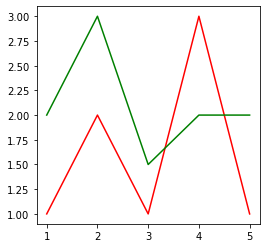

In [62]:
x = [1,2,3,4,5]
y = [1,2,1,3,1]
z = [2,3,1.5,2,2]
plt.plot(x,y,color="red")
plt.plot(x,z,color="green")

plt.show(); # semicolon needed to remove text output on top

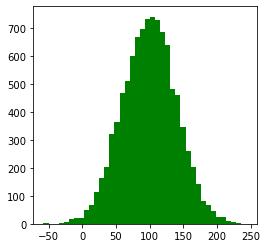

In [63]:
# create array or random numbers distributed normally
x = np.random.normal(loc=100.0, scale=40.0, size=10**4)
plt.hist(x,bins=40,color="green")
plt.show();

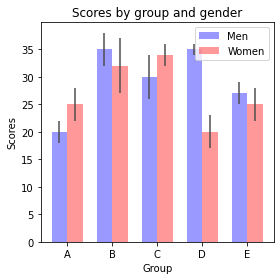

In [64]:
# Barchart 
n_groups = 5

means_men = (20, 35, 30, 35, 27)
std_men = (2, 3, 4, 1, 2)

means_women = (25, 32, 34, 20, 25)
std_women = (3, 5, 2, 3, 3)

fig, ax = plt.subplots()

index = np.arange(n_groups)
bar_width = 0.35

opacity = 0.4
error_config = {'ecolor': '0.3'}

rects1 = ax.bar(index, means_men, bar_width,
                alpha=opacity, color='b',
                yerr=std_men, error_kw=error_config,
                label='Men')

rects2 = ax.bar(index + bar_width, means_women, bar_width,
                alpha=opacity, color='r',
                yerr=std_women, error_kw=error_config,
                label='Women')

ax.set_xlabel('Group')
ax.set_ylabel('Scores')
ax.set_title('Scores by group and gender')
ax.set_xticks(index + bar_width / 2)
ax.set_xticklabels(('A', 'B', 'C', 'D', 'E'))
ax.legend()

fig.tight_layout()
plt.show();

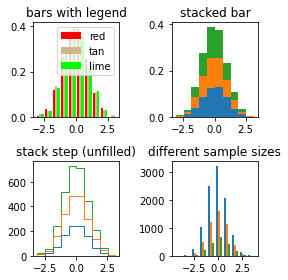

In [65]:
# Multiple graphs

np.random.seed(0)

n_bins = 10
x = np.random.randn(1000, 3)

fig, axes = plt.subplots(nrows=2, ncols=2)
ax0, ax1, ax2, ax3 = axes.flatten()

# row,col = 0,0
colors = ['red', 'tan', 'lime']
ax0.hist(x, n_bins, density=1, histtype='bar', color=colors, label=colors)
ax0.legend(prop={'size': 10})
ax0.set_title('bars with legend')

# row,col = 0,1
ax1.hist(x, n_bins, density=1, histtype='bar', stacked=True)
ax1.set_title('stacked bar')

# row,col = 1,0
ax2.hist(x, n_bins, histtype='step', stacked=True, fill=False)
ax2.set_title('stack step (unfilled)')

# row,col = 1,1
# Make a multiple-histogram of data-sets with different length.
x_multi = [np.random.randn(n) for n in [10000, 5000, 2000]]
ax3.hist(x_multi, n_bins, histtype='bar')
ax3.set_title('different sample sizes')

fig.tight_layout()
plt.show() ;

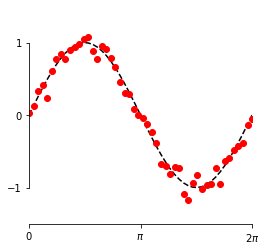

In [66]:
# graph with points and line (model)

x = np.linspace(0, 2*np.pi, 50) # evenly-spreaded 50 points
y = np.sin(x)                                 # sin() wave
y2 = y + 0.1 * np.random.normal(size=x.shape) # noisy data

fig, ax = plt.subplots()
ax.plot(x, y, 'k--')
ax.plot(x, y2, 'ro')

# set ticks and tick labels
ax.set_xlim((0, 2*np.pi))
ax.set_xticks([0, np.pi, 2*np.pi])
ax.set_xticklabels(['0', '$\pi$', '2$\pi$'])
ax.set_ylim((-1.5, 1.5))
ax.set_yticks([-1, 0, 1])

# Only draw spine between the y-ticks
ax.spines['left'].set_bounds(-1, 1)
# Hide the right and top spines
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)
# Only show ticks on the left and bottom spines
ax.yaxis.set_ticks_position('left')
ax.xaxis.set_ticks_position('bottom')

plt.show();  # semicolon to remove text output !!

In [67]:
# make two sets of values shifted a bit one from another
N=1000
x1 = list(np.random.randint(1,10,N)) # 300 numbers 1..9   # before
x2 = list(np.random.normal(loc=0.0, scale=1, size=N))   # shift
mydict = {} # dictionary of all combinations 
for ii in range(N):
    x2[ii] = x1[ii] + round(x2[ii])
    x2[ii] = max(1,x2[ii])
    x2[ii] = min(9,x2[ii])    
    tup = (x1[ii],x2[ii])     # (before, after)
    if tup in mydict:
        mydict[tup] += 1
    else:
        mydict[tup] = 1
tups = list(mydict.keys())
xx = [el[0] for el in tups]
yy = [el[1] for el in tups]
zz = [48* mydict[kk] for kk in tups]  # array of sizes for dots
print(f"xx = {xx}\n\nyy = {yy}\n\nzz = {zz}")

xx = [4, 9, 3, 8, 9, 6, 7, 7, 7, 1, 5, 5, 7, 5, 1, 6, 5, 3, 4, 8, 3, 6, 2, 8, 2, 4, 4, 2, 2, 4, 9, 8, 9, 3, 1, 4, 7, 6, 3, 4, 5, 6, 5, 6]

yy = [4.0, 8.0, 3.0, 9, 9, 6.0, 6.0, 8.0, 9, 2.0, 4.0, 7.0, 7.0, 6.0, 1, 7.0, 5.0, 2.0, 5.0, 8.0, 5.0, 5.0, 2.0, 7.0, 1, 6.0, 2.0, 3.0, 4.0, 3.0, 6.0, 6.0, 7.0, 4.0, 3.0, 7.0, 5.0, 4.0, 1, 1, 3.0, 3.0, 8.0, 8.0]

zz = [2160, 1584, 1584, 1536, 3312, 2160, 1200, 1392, 432, 1008, 1296, 624, 2544, 1344, 3456, 1728, 2544, 1392, 1248, 1968, 240, 1056, 1824, 1440, 1392, 528, 672, 816, 336, 1632, 96, 288, 192, 1008, 336, 96, 480, 240, 240, 48, 288, 48, 48, 144]


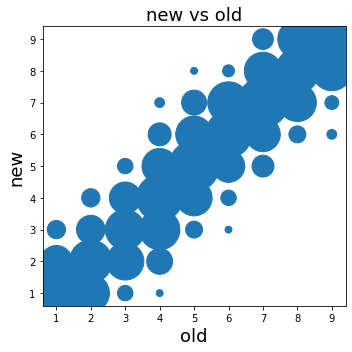

In [68]:
# note - use subplots although we are making only one plot
fig, axes = plt.subplots( nrows=1, ncols=1, figsize=(5,5) )
ax0 = axes

# scatterplot - show dots bigger if there are more events at this dot
myscatter = ax0.scatter(xx, yy,s=zz)
ax0.set_title('new vs old', fontsize=18)
plt.xlabel("old", fontsize=18)
plt.ylabel("new", fontsize=18)
fig.tight_layout()
plt.show() ;

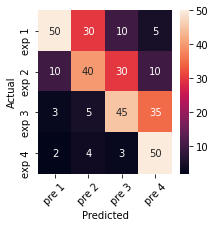

In [69]:
# Several methods of plotting a heatmap (for confusion matrix, etc.).
# https://stackoverflow.com/questions/33282368/plotting-a-2d-heatmap-with-matplotlib

import matplotlib.pyplot as plt
import seaborn as sns
my_matrix = [[50,30,10, 5],
             [10,40,30,10],
             [ 3, 5,45,35],
             [ 2, 4, 3,50]]

labels_expected  = ['exp 1','exp 2','exp 3','exp 4']
labels_predicted = ['pre 1','pre 2','pre 3','pre 4']

fig, ax = plt.subplots(figsize=(3,3))
_=sns.heatmap(my_matrix, 
            annot=True, fmt='d', 
            xticklabels=labels_predicted, 
            yticklabels=labels_expected)
_=plt.ylabel('Actual')
_=plt.xlabel('Predicted')
_=plt.xticks(rotation=45)
_=plt.show()

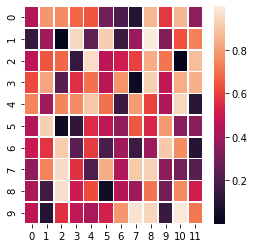

In [70]:
import numpy as np
import seaborn as sns
import matplotlib.pylab as plt

uniform_data = np.random.rand(10, 12)
ax = sns.heatmap(uniform_data, linewidth=0.5)
plt.show();

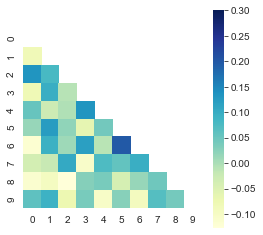

In [71]:
import numpy as np
import seaborn as sns
import matplotlib.pylab as plt

corr = np.corrcoef(np.random.randn(10, 200))
mask = np.zeros_like(corr)
mask[np.triu_indices_from(mask)] = True
with sns.axes_style("white"):
    ax = sns.heatmap(corr, mask=mask, vmax=.3, square=True,  cmap="YlGnBu")
    plt.show();

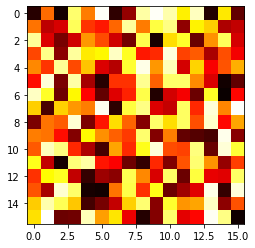

In [72]:
import matplotlib.pyplot as plt
import numpy as np

a = np.random.random((16, 16))
plt.imshow(a, cmap='hot', interpolation='nearest')
plt.show();

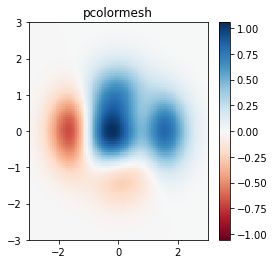

In [73]:
import numpy as np
import matplotlib.pyplot as plt

# generate data
y, x = np.meshgrid(np.linspace(-3, 3, 100), np.linspace(-3, 3, 100))
z = (1 - x / 2. + x ** 5 + y ** 3) * np.exp(-x ** 2 - y ** 2)
z = z[:-1, :-1]
z_min, z_max = -np.abs(z).max(), np.abs(z).max()

# plot
fig, ax = plt.subplots()
c = ax.pcolormesh(x, y, z, cmap='RdBu', vmin=z_min, vmax=z_max)
ax.set_title('pcolormesh')
ax.axis([x.min(), x.max(), y.min(), y.max()])
fig.colorbar(c, ax=ax)
plt.show();

In [74]:
import numpy as np
import matplotlib.pyplot as plt
import itertools

def plot_confusion_matrix(cm, 
                          mytitle="Title", 
                          classes=['0', '1'],
                          cmap=plt.cm.Blues, 
                          save=False, 
                          saveas="MyFigure.png"):
    """
    # print Confusion matrix with blue gradient colours
    # cm = metrics.confusion_matrix(y_expected, y_predicted)
    # Typical usage:
    #   plot_confusion_matrix(cm, mytitle="Some Title")
    """
    if type(cm) == list:
        cm = np.array(cm)
    cm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
    
    plt.imshow(cm, interpolation='nearest', cmap=cmap)
    plt.title(mytitle)
    plt.colorbar()
    tick_marks = np.arange(len(classes))
    plt.xticks(tick_marks, classes, rotation=90)
    plt.yticks(tick_marks, classes)

    fmt = '.1%'
    thresh = cm.max() / 2.
    for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
        plt.text(j, i, format(cm[i, j], fmt),
                 horizontalalignment="center",
                 color="white" if cm[i, j] > thresh else "black")

    plt.tight_layout()
    plt.ylabel('True label')
    plt.xlabel('Predicted label')
    
    if save:
        plt.savefig(saveas, dpi=100)

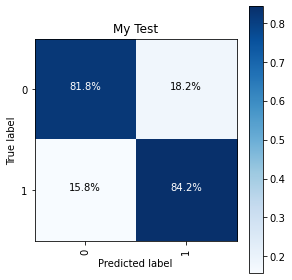

In [75]:
confusion_matrix = np.array([[90,20],[15,80]])
plot_confusion_matrix(confusion_matrix, mytitle="My Test")